<a href="https://colab.research.google.com/github/joseph-ambali/Final-Year-Project---CYB-497-CYB498/blob/main/Experimental_setup_phishing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

“An Enhanced Phishing Detection System Using An Integrated Behavioural-Linguistic Machine Learning Approach" - Joseph Oluwatimilehin Ambali (#2023/B/CYB/0113 #30023809)
*** ***
The implementation consists of five key stages: dataset alignment and fusion, preprocessing of textual and numerical features, multimodal deep learning model construction, behavioural model training, and final prediction through weighted fusion. The text-based LSTM model captures linguistic phishing patterns, while the behavioural model learns user interaction characteristics. Both outputs are combined using a weighted averaging strategy to produce the final classification, which is evaluated using standard performance metrics and confusion matrix analysis.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install shap lime seaborn joblib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 23.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


import libraries

In [ ]:
import os, json, joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (Input, Embedding, LSTM, Dense,
                                     Dropout, Concatenate)
from tensorflow.keras.models import Model
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
 def plot_confusion_matrix(y_true, y_pred_bin, class_names, title):
    cm      = confusion_matrix(y_true, y_pred_bin)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=axes[0], annot_kws={"size": 13})
    axes[0].set_title(f"{title}\nConfusion Matrix (Counts)",
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Predicted Label", fontsize=11)
    axes[0].set_ylabel("True Label", fontsize=11)

    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, vmin=0, vmax=1, ax=axes[1],
                annot_kws={"size": 13})
    axes[1].set_title(f"{title}\nConfusion Matrix (Normalised)",
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Predicted Label", fontsize=11)
    axes[1].set_ylabel("True Label", fontsize=11)

    plt.tight_layout()
    plt.show()
    plt.close('all')


def plot_classification_report_heatmap(y_true, y_pred_bin,
                                        class_names, title):
    report  = classification_report(y_true, y_pred_bin,
                                    target_names=class_names, output_dict=True)
    df_rep  = pd.DataFrame(report).transpose()
    rows    = class_names + ['accuracy', 'macro avg', 'weighted avg']
    df_rep  = df_rep.loc[[r for r in rows if r in df_rep.index]]
    df_plot = df_rep[['precision', 'recall', 'f1-score']].astype(float)

    fig, ax = plt.subplots(figsize=(8, max(4, len(df_plot) * 0.8)))
    sns.heatmap(df_plot, annot=True, fmt=".3f", cmap="YlGnBu",
                linewidths=0.5, vmin=0, vmax=1, ax=ax,
                annot_kws={"size": 11, "weight": "bold"})
    ax.set_title(f"{title}\nClassification Report Heatmap",
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("Metrics", fontsize=11)
    ax.set_ylabel("Classes", fontsize=11)
    plt.tight_layout()
    plt.show()
    plt.close('all')


def plot_roc_curve(y_true, y_pred_prob, title):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc  = auc(fpr, tpr)
    best_idx = np.argmax(tpr - fpr)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, color='royalblue', lw=2.5,
            label=f'ROC Curve (AUC = {roc_auc:.4f})')
    ax.fill_between(fpr, tpr, alpha=0.08, color='royalblue')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
    ax.scatter(fpr[best_idx], tpr[best_idx], color='red', s=120, zorder=5,
               label=f'Best Threshold = {thresholds[best_idx]:.3f}')
    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{title}\nROC Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close('all')
    return roc_auc

Load Email / Text Dataset

In [ ]:
email_df = pd.read_csv(
    "/content/drive/MyDrive/dataset_project_miva_cyb_497/legit_phishing_email.csv"
).dropna(subset=['text_combined', 'label'])

for col in ['url_length', 'domain_age', 'mouse_speed_variance', 'click_hesitation_ms']:
    if col not in email_df.columns:
        email_df[col] = 0
    else:
        email_df[col] = email_df[col].fillna(0)

email_df['label'] = email_df['label'].astype(int)
print(f"Email dataset: {len(email_df)} rows, {email_df['label'].value_counts().to_dict()}")

Email dataset: 82486 rows, {1: 42891, 0: 39595}


Load URL Dataset

In [ ]:
url_df = pd.read_csv("/content/drive/MyDrive/dataset_project_miva_cyb_497/legit_phishing_url.csv").dropna()
url_df['label'] = (url_df['status'] == 'phishing').astype(int)
url_df = url_df.drop(columns=['url', 'status'], errors='ignore')
url_df = url_df.select_dtypes(include=[np.number])
print(f"URL dataset: {len(url_df)} rows, {url_df['label'].value_counts().to_dict()}")

URL dataset: 11430 rows, {0: 5715, 1: 5715}


Load Mouse Dataset & Extract Features

In [ ]:

def extract_mouse_features(file_path):
    try:
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip().str.replace(' ', '_')
        df['dx'] = df['x'].diff().fillna(0)
        df['dy'] = df['y'].diff().fillna(0)
        df['dt'] = df['client_timestamp'].diff().replace(0, np.nan).fillna(0.01)
        speed = (np.sqrt(df['dx']**2 + df['dy']**2) / df['dt']
                 ).replace([np.inf, -np.inf], np.nan).fillna(0)
        return {
            'avg_speed':   float(speed.mean()),
            'speed_var':   float(speed.var()),
            'clicks':      int((df['state'] == 'Pressed').sum()),
            'hesitation':  float(df['dt'].mean())
        }
    except Exception:
        return None


def load_mouse_folder(folder, limit=500):
    data, count = [], 0
    for root, _, files in os.walk(folder):
        for f in files:
            if count >= limit: break
            feat = extract_mouse_features(os.path.join(root, f))
            if feat:
                data.append(feat); count += 1
    return pd.DataFrame(data)


mouse_df = pd.concat([
    load_mouse_folder(
        "/content/drive/MyDrive/dataset_project_miva_cyb_497/Mouse-Dynamics-Challenge-master/Mouse-Dynamics-Challenge-master/training_files", 400),
    load_mouse_folder(
        "/content/drive/MyDrive/dataset_project_miva_cyb_497/Mouse-Dynamics-Challenge-master/Mouse-Dynamics-Challenge-master/test_files", 200)
], ignore_index=True)

mouse_stats = {
    'avg_speed_mean': float(mouse_df['avg_speed'].mean()),
    'avg_speed_std':  max(float(mouse_df['avg_speed'].std()), 1e-6),
    'speed_var_mean': float(mouse_df['speed_var'].mean()),
    'speed_var_std':  max(float(mouse_df['speed_var'].std()), 1e-6),
}
json.dump(mouse_stats, open("mouse_stats.json", "w"))
print("Mouse stats saved:", mouse_stats)

Mouse stats saved: {'avg_speed_mean': 1881.8271587464026, 'avg_speed_std': 4834.581137261184, 'speed_var_mean': 8616941690.993864, 'speed_var_std': 41350029480.17767}


MOUSE BEHAVIOUR MODEL

In [ ]:
MOUSE_FEATURES = ['mouse_speed_variance', 'click_hesitation_ms']

X_mouse = email_df[MOUSE_FEATURES].values.astype(np.float32)
y_mouse = email_df['label'].values

(X_mouse_train, X_mouse_test,
 y_mouse_train, y_mouse_test) = train_test_split(
    X_mouse, y_mouse, test_size=0.2, stratify=y_mouse, random_state=42)

scaler_mouse    = StandardScaler()
X_mouse_train_s = scaler_mouse.fit_transform(X_mouse_train)
X_mouse_test_s  = scaler_mouse.transform(X_mouse_test)

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_mouse_train_poly = poly.fit_transform(X_mouse_train_s)
X_mouse_test_poly  = poly.transform(X_mouse_test_s)

print("\n" + "="*60)
print("TRAINING: MOUSE BEHAVIOUR MODEL (Random Forest + Poly Features)")
print("="*60)

mouse_model = RandomForestClassifier(
    n_estimators=300, max_depth=8,
    min_samples_leaf=2, n_jobs=-1, random_state=42)
mouse_model.fit(X_mouse_train_poly, y_mouse_train)

pred_mouse_prob = mouse_model.predict_proba(X_mouse_test_poly)[:, 1]
pred_mouse_bin  = (pred_mouse_prob > 0.5).astype(int)

print("\n=== MOUSE BEHAVIOUR MODEL — Classification Report ===")
print(classification_report(y_mouse_test, pred_mouse_bin,
                             target_names=['Legitimate', 'Phishing']))




TRAINING: MOUSE BEHAVIOUR MODEL (Random Forest + Poly Features)

=== MOUSE BEHAVIOUR MODEL — Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.00      0.00      0.00      7919
    Phishing       0.52      1.00      0.68      8579

    accuracy                           0.52     16498
   macro avg       0.26      0.50      0.34     16498
weighted avg       0.27      0.52      0.36     16498



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Text + Numerical — Data Prep

In [ ]:
TEXT_MAXLEN       = 200
TEXT_VOCAB        = 15000
TEXT_NUM_FEATURES = ['url_length', 'domain_age',
                     'mouse_speed_variance', 'click_hesitation_ms']

X_text  = email_df['text_combined'].astype(str)
X_num   = email_df[TEXT_NUM_FEATURES].values.astype(np.float32)
y_email = email_df['label'].values

(X_text_train, X_text_test,
 X_num_train,  X_num_test,
 y_text_train, y_text_test) = train_test_split(
    X_text, X_num, y_email,
    test_size=0.2, stratify=y_email, random_state=42)

tokenizer = Tokenizer(num_words=TEXT_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_text_train)

X_seq_train = pad_sequences(
    tokenizer.texts_to_sequences(X_text_train), maxlen=TEXT_MAXLEN)
X_seq_test  = pad_sequences(
    tokenizer.texts_to_sequences(X_text_test),  maxlen=TEXT_MAXLEN)

scaler_text_num  = StandardScaler()
X_num_train_s    = scaler_text_num.fit_transform(X_num_train)
X_num_test_s     = scaler_text_num.transform(X_num_test)

Build & Train LSTM Text Model

In [ ]:
seq_input = Input(shape=(TEXT_MAXLEN,), name='text_input')
x = Embedding(TEXT_VOCAB, 128)(seq_input)
x = LSTM(64, dropout=0.2)(x)
x = Dense(32, activation='relu')(x)

num_input = Input(shape=(len(TEXT_NUM_FEATURES),), name='num_input')
n = Dense(16, activation='relu')(num_input)

merged   = Concatenate()([x, n])
merged   = Dropout(0.3)(merged)
merged   = Dense(32, activation='relu')(merged)
text_out = Dense(1, activation='sigmoid', name='text_out')(merged)

text_model = Model(inputs=[seq_input, num_input], outputs=text_out)
text_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
text_model.summary()

print("\n" + "="*60)
print("TRAINING: TEXT / LSTM MODEL")
print("="*60)
text_history = text_model.fit(
    [X_seq_train, X_num_train_s], y_text_train,
    validation_split=0.1, epochs=6, batch_size=32)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  1,920,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     49,408 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_input           │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │         80 │ num_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48)        │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,568 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_out (Dense)    │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,973,169 (7.53 MB)

 Trainable params: 1,973,169 (7.53 MB)

 Non-trainable params: 0 (0.00 B)


TRAINING: TEXT / LSTM MODEL
Epoch 1/6
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - accuracy: 0.9658 - loss: 0.0962 - val_accuracy: 0.9862 - val_loss: 0.0507
Epoch 2/6
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9906 - loss: 0.0309 - val_accuracy: 0.9851 - val_loss: 0.0455
Epoch 3/6
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9953 - loss: 0.0153 - val_accuracy: 0.9885 - val_loss: 0.0428
Epoch 4/6
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9973 - loss: 0.0087 - val_accuracy: 0.9883 - val_loss: 0.0377
Epoch 5/6
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9979 - loss: 0.0069 - val_accuracy: 0.9885 - val_loss: 0.0632
Epoch 6/6
1856/1856 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9990 - loss: 0.0038 - val_accuracy: 0.9856 - val_loss: 0.0580


Evaluate LSTM Text Model

516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

=== TEXT MODEL — Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99      7919
    Phishing       0.99      0.98      0.99      8579

    accuracy                           0.99     16498
   macro avg       0.99      0.99      0.99     16498
weighted avg       0.99      0.99      0.99     16498



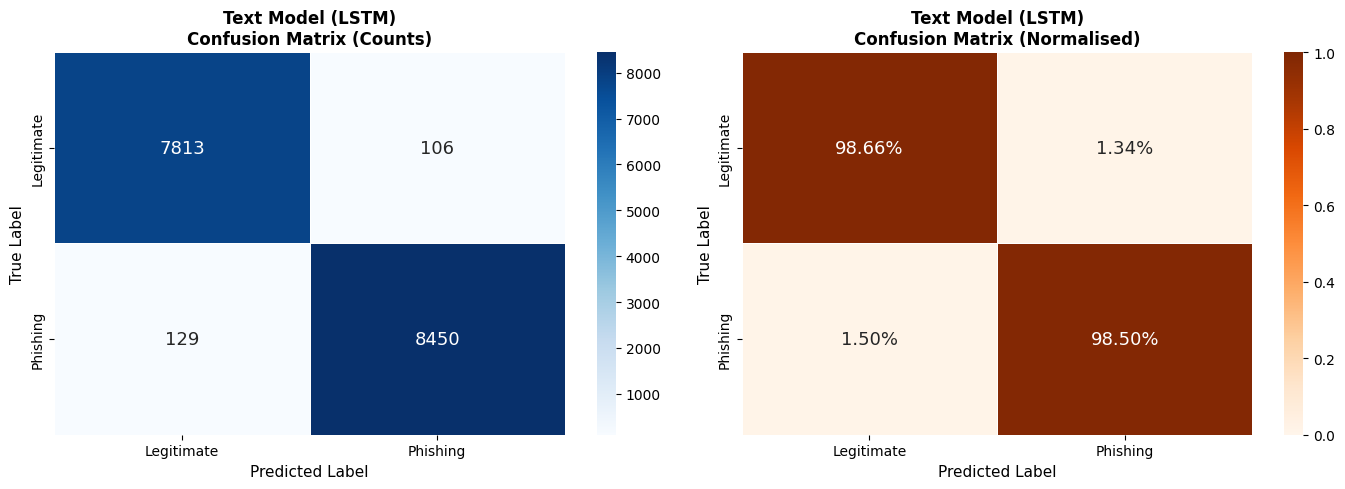

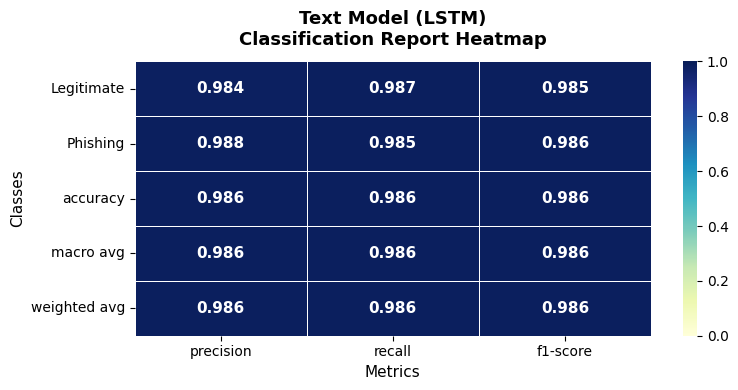

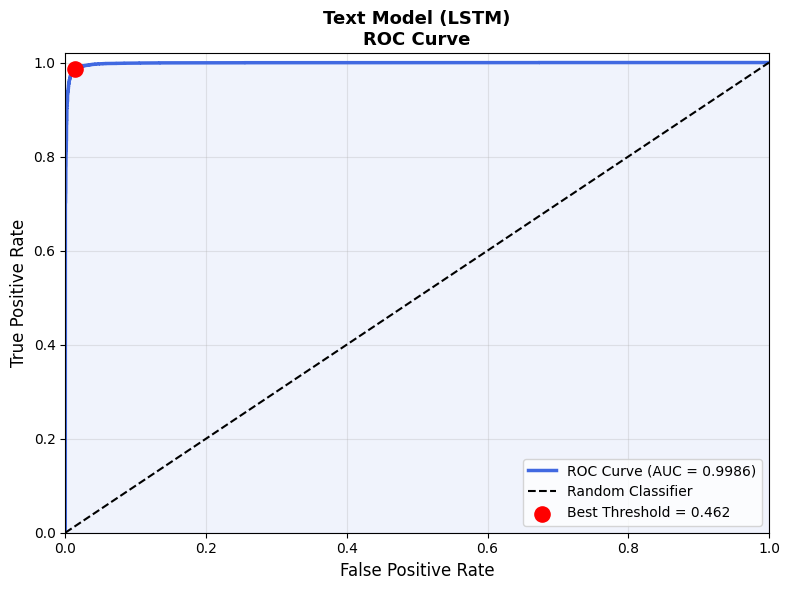

np.float64(0.9985845142258867)

In [ ]:
pred_text_prob = text_model.predict([X_seq_test, X_num_test_s]).flatten()
pred_text_bin  = (pred_text_prob > 0.5).astype(int)

print("\n=== TEXT MODEL — Classification Report ===")
print(classification_report(y_text_test, pred_text_bin,
                             target_names=['Legitimate', 'Phishing']))

plot_confusion_matrix(y_text_test, pred_text_bin,
                      ['Legitimate', 'Phishing'],
                      "Text Model (LSTM)")

plot_classification_report_heatmap(y_text_test, pred_text_bin,
                                   ['Legitimate', 'Phishing'],
                                   "Text Model (LSTM)")

plot_roc_curve(y_text_test, pred_text_prob,
               "Text Model (LSTM)")

MULTIMODAL FUSION (Email Text + Mouse Behavior)


MULTIMODAL FUSION: Text LSTM  +  Mouse Behaviour

Fusion weights — Text: 0.7, Mouse: 0.3

=== MULTIMODAL FUSION — Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99      7919
    Phishing       0.99      0.99      0.99      8579

    accuracy                           0.99     16498
   macro avg       0.99      0.99      0.99     16498
weighted avg       0.99      0.99      0.99     16498



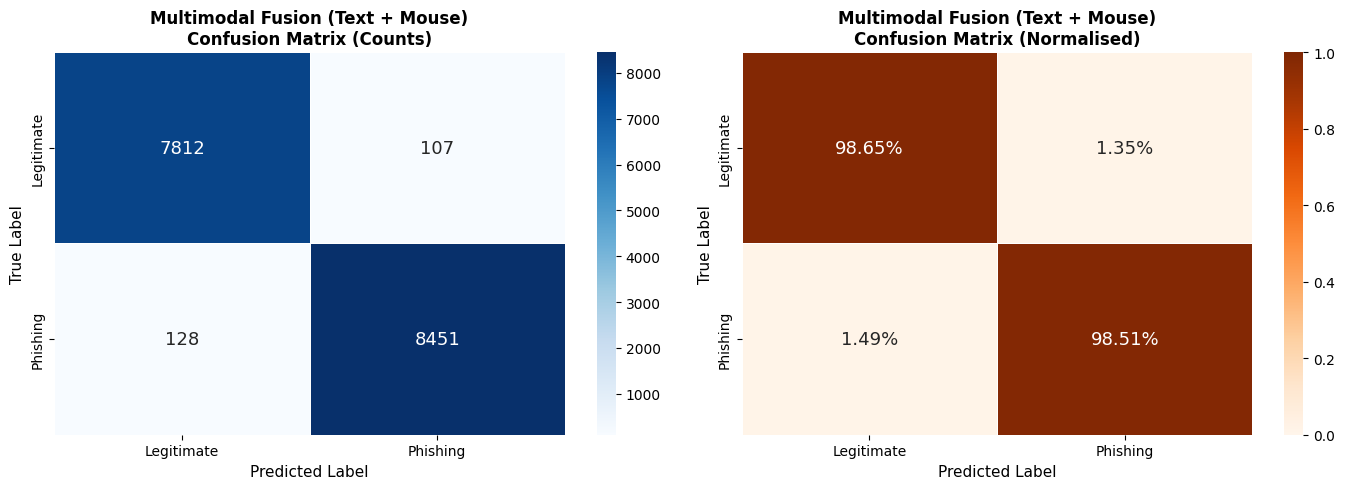

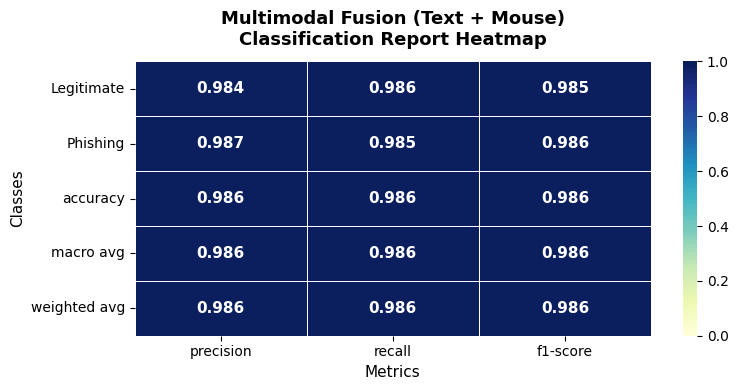

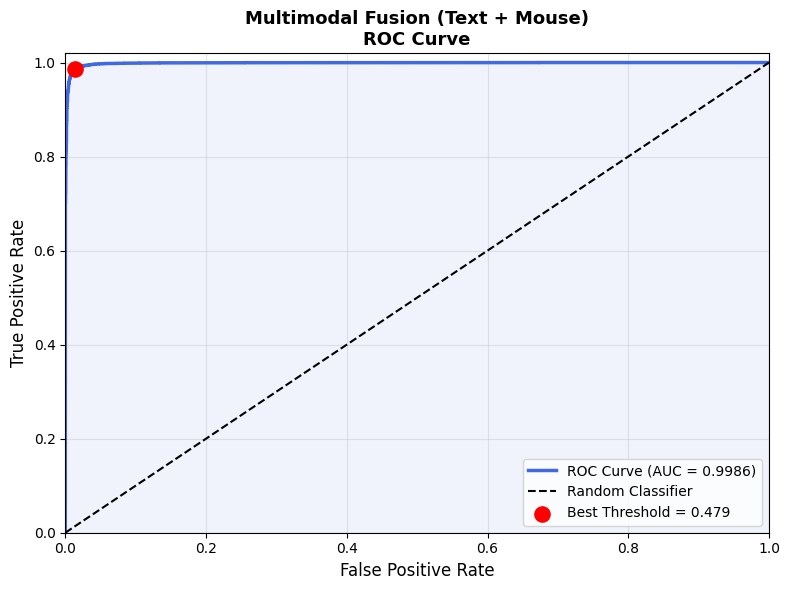

np.float64(0.9985845142258867)

In [ ]:
print("\n" + "="*60)
print("MULTIMODAL FUSION: Text LSTM  +  Mouse Behaviour")
print("="*60)

X_mouse_test_aligned_s    = scaler_mouse.transform(
    X_num_test[:, [TEXT_NUM_FEATURES.index('mouse_speed_variance'),
                   TEXT_NUM_FEATURES.index('click_hesitation_ms')]])
X_mouse_test_aligned_poly = poly.transform(X_mouse_test_aligned_s)

pred_mouse_aligned_prob = mouse_model.predict_proba(
    X_mouse_test_aligned_poly)[:, 1]

WEIGHT_TEXT  = 0.70
WEIGHT_MOUSE = 0.30
pred_fusion_prob = (WEIGHT_TEXT  * pred_text_prob +
                    WEIGHT_MOUSE * pred_mouse_aligned_prob)
pred_fusion_bin  = (pred_fusion_prob > 0.5).astype(int)

print(f"\nFusion weights — Text: {WEIGHT_TEXT}, Mouse: {WEIGHT_MOUSE}")
print("\n=== MULTIMODAL FUSION — Classification Report ===")
print(classification_report(y_text_test, pred_fusion_bin,
                             target_names=['Legitimate', 'Phishing']))

plot_confusion_matrix(y_text_test, pred_fusion_bin,
                      ['Legitimate', 'Phishing'],
                      "Multimodal Fusion (Text + Mouse)")

plot_classification_report_heatmap(y_text_test, pred_fusion_bin,
                                   ['Legitimate', 'Phishing'],
                                   "Multimodal Fusion (Text + Mouse)")

plot_roc_curve(y_text_test, pred_fusion_prob,
               "Multimodal Fusion (Text + Mouse)")

URL Dataset — Data Prep & Train Dense Model

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ url_input (InputLayer)          │ (None, 87)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        11,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ url_out (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,585 (76.50 KB)

 Trainable params: 19,585 (76.50 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING: URL FEATURE MODEL
Epoch 1/8
129/129 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8848 - loss: 0.2924 - val_accuracy: 0.9399 - val_loss: 0.1583
Epoch 2/8
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9349 - loss: 0.1715 - val_accuracy: 0.9454 - val_loss: 0.1408
Epoch 3/8
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9453 - loss: 0.1517 - val_accuracy: 0.9541 - val_loss: 0.1377
Epoch 4/8
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9509 - loss: 0.1378 - val_accuracy: 0.9574 - val_loss: 0.1302
Epoch 5/8
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9546 - loss: 0.1303 - val_accuracy: 0.9596 - val_loss: 0.1354
Epoch 6/8
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9559 - loss: 0.1278 - val_accuracy: 0.9563 - val_loss: 0.1297
Epoch 7/8
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9593 - loss: 0.1148 - val_accuracy: 0.9585 - val_loss: 0.1279
Epoch 8/8
129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9593 - loss: 0.1

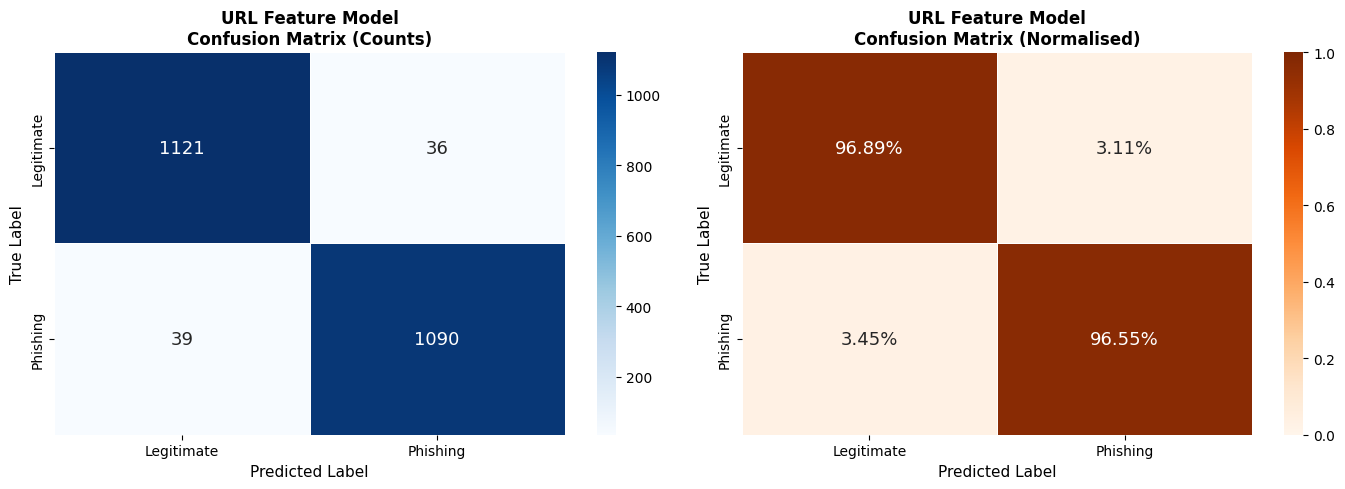

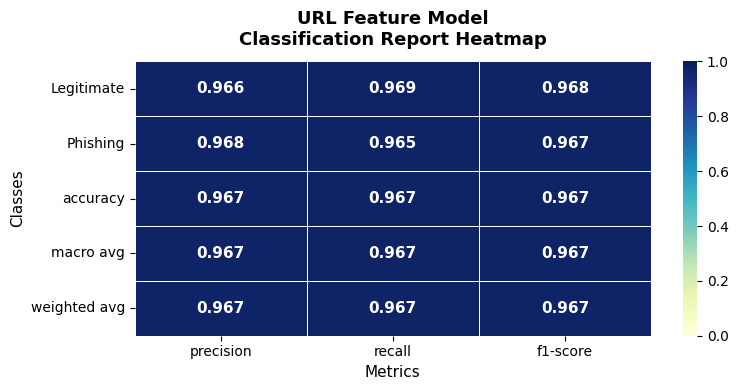

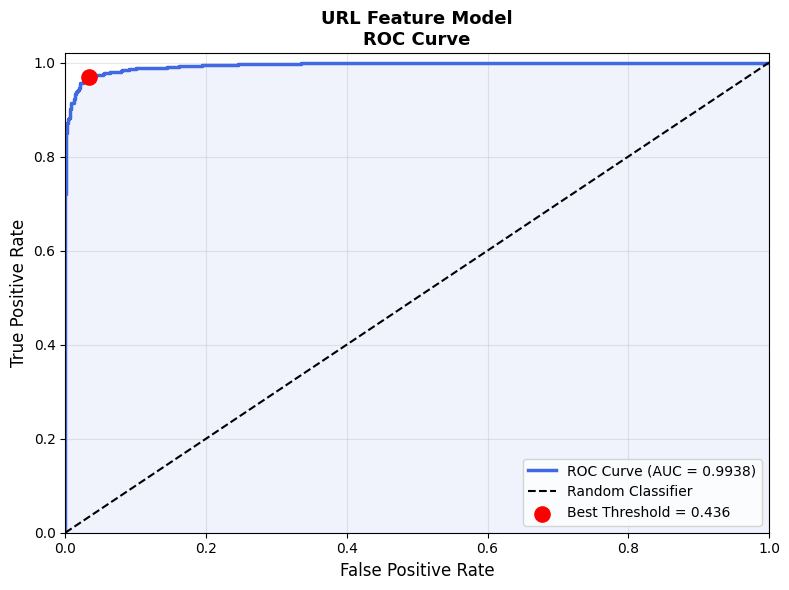

np.float64(0.9938472868579058)

In [ ]:
X_url = url_df.drop(columns=['label'])
y_url = url_df['label'].values

url_columns = X_url.columns.tolist()
json.dump(url_columns, open("url_columns.json", "w"))

X_url_train, X_url_test, y_url_train, y_url_test = train_test_split(
    X_url.values, y_url, test_size=0.2, random_state=42)

scaler_url    = StandardScaler()
X_url_train_s = scaler_url.fit_transform(X_url_train)
X_url_test_s  = scaler_url.transform(X_url_test)

url_input = Input(shape=(len(url_columns),), name='url_input')
u = Dense(128, activation='relu')(url_input)
u = Dropout(0.3)(u)
u = Dense(64,  activation='relu')(u)
u = Dropout(0.2)(u)
url_out = Dense(1, activation='sigmoid', name='url_out')(u)

url_model = Model(inputs=url_input, outputs=url_out)
url_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
url_model.summary()

print("\n" + "="*60)
print("TRAINING: URL FEATURE MODEL")
print("="*60)
url_history = url_model.fit(
    X_url_train_s, y_url_train,
    validation_split=0.1, epochs=8, batch_size=64)

pred_url_prob = url_model.predict(X_url_test_s).flatten()
pred_url_bin  = (pred_url_prob > 0.5).astype(int)

print("\n=== URL MODEL — Classification Report ===")
print(classification_report(y_url_test, pred_url_bin,
                             target_names=['Legitimate', 'Phishing']))

plot_confusion_matrix(y_url_test, pred_url_bin,
                      ['Legitimate', 'Phishing'],
                      "URL Feature Model")

plot_classification_report_heatmap(y_url_test, pred_url_bin,
                                   ['Legitimate', 'Phishing'],
                                   "URL Feature Model")

plot_roc_curve(y_url_test, pred_url_prob,
               "URL Feature Model")

Naive Bayes


TRAINING: NAIVE BAYES

=== NAIVE BAYES — Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.62      0.98      0.76      1157
    Phishing       0.94      0.38      0.54      1129

    accuracy                           0.68      2286
   macro avg       0.78      0.68      0.65      2286
weighted avg       0.78      0.68      0.65      2286



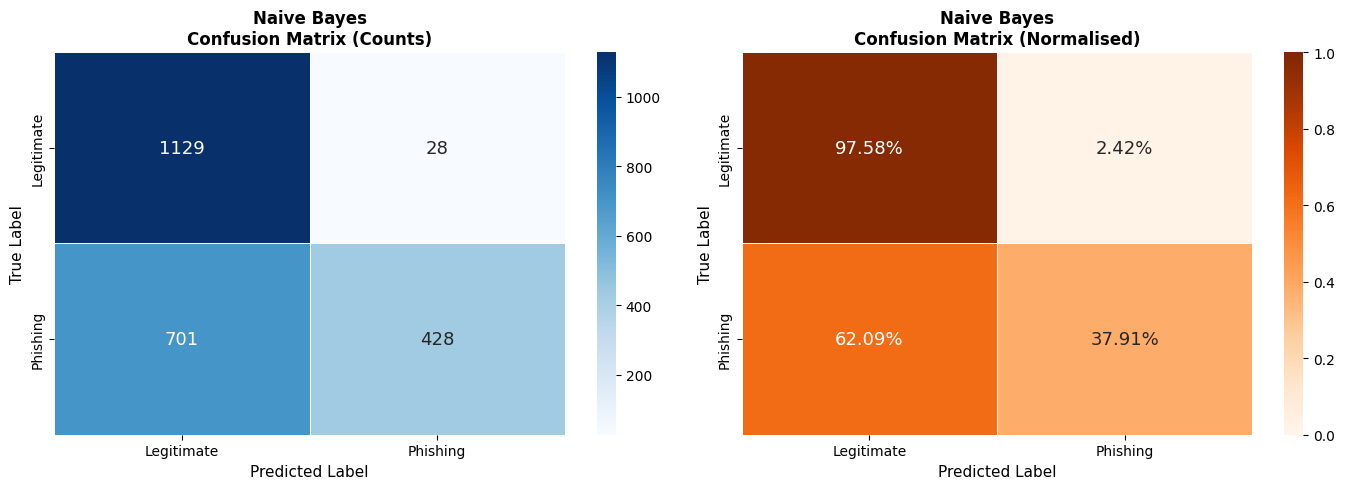

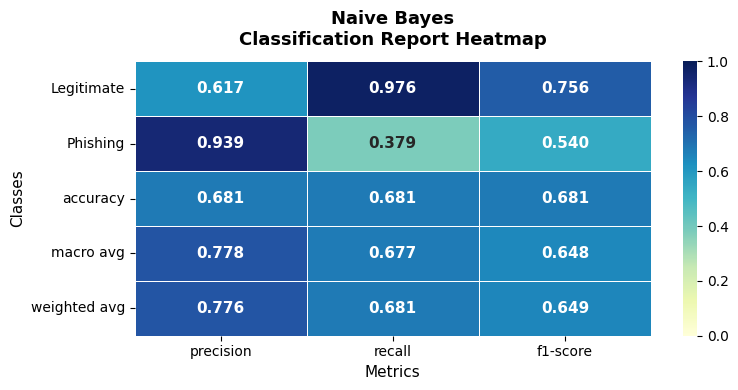

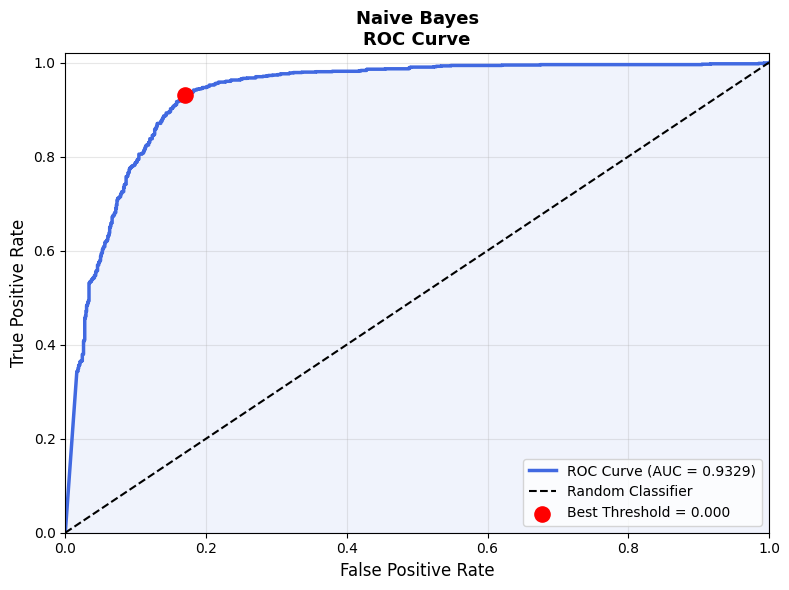

np.float64(0.9328904890553361)

In [ ]:
print("\n" + "="*60)
print("TRAINING: NAIVE BAYES")
print("="*60)

nb_model     = GaussianNB()
nb_model.fit(X_url_train_s, y_url_train)
pred_nb_prob = nb_model.predict_proba(X_url_test_s)[:, 1]
pred_nb_bin  = (pred_nb_prob > 0.5).astype(int)

print("\n=== NAIVE BAYES — Classification Report ===")
print(classification_report(y_url_test, pred_nb_bin,
                             target_names=['Legitimate', 'Phishing']))

plot_confusion_matrix(y_url_test, pred_nb_bin,
                      ['Legitimate', 'Phishing'],
                      "Naive Bayes")

plot_classification_report_heatmap(y_url_test, pred_nb_bin,
                                   ['Legitimate', 'Phishing'],
                                   "Naive Bayes")

plot_roc_curve(y_url_test, pred_nb_prob,
               "Naive Bayes")

SVM


TRAINING: SVM (LinearSVC + Calibration)

=== SVM — Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.95      0.96      0.96      1157
    Phishing       0.96      0.95      0.96      1129

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



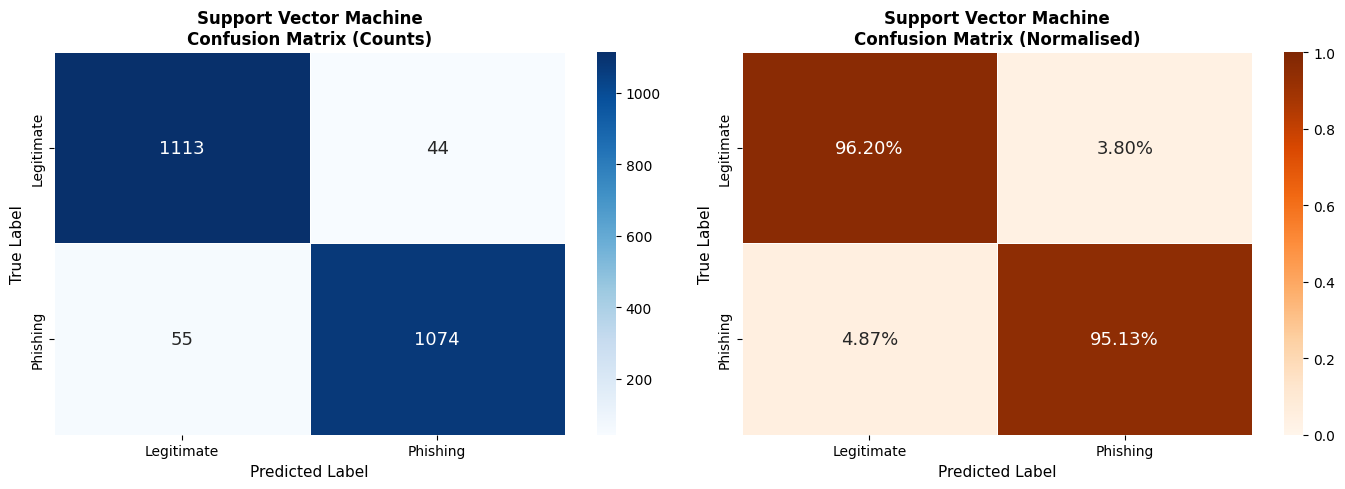

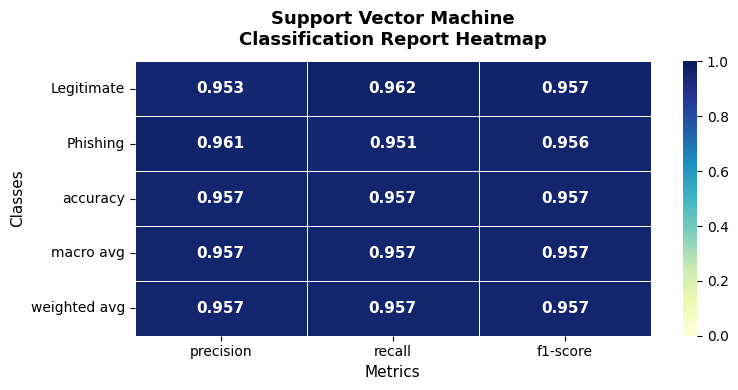

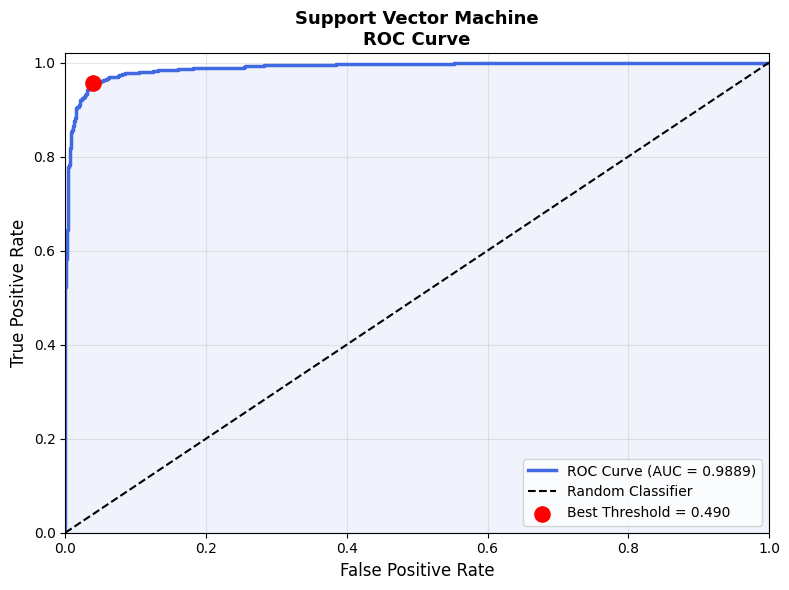

np.float64(0.9889355278035726)

In [ ]:
print("\n" + "="*60)
print("TRAINING: SVM (LinearSVC + Calibration)")
print("="*60)

svm_model = CalibratedClassifierCV(
    LinearSVC(max_iter=2000, random_state=42), cv=3)
svm_model.fit(X_url_train_s, y_url_train)
pred_svm_prob = svm_model.predict_proba(X_url_test_s)[:, 1]
pred_svm_bin  = (pred_svm_prob > 0.5).astype(int)

print("\n=== SVM — Classification Report ===")
print(classification_report(y_url_test, pred_svm_bin,
                             target_names=['Legitimate', 'Phishing']))

plot_confusion_matrix(y_url_test, pred_svm_bin,
                      ['Legitimate', 'Phishing'],
                      "Support Vector Machine")

plot_classification_report_heatmap(y_url_test, pred_svm_bin,
                                   ['Legitimate', 'Phishing'],
                                   "Support Vector Machine")

plot_roc_curve(y_url_test, pred_svm_prob,
               "Support Vector Machine")

Random Forest


TRAINING: RANDOM FOREST

=== RANDOM FOREST — Classification Report ===
              precision    recall  f1-score   support

  Legitimate       0.96      0.97      0.97      1157
    Phishing       0.97      0.96      0.97      1129

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286



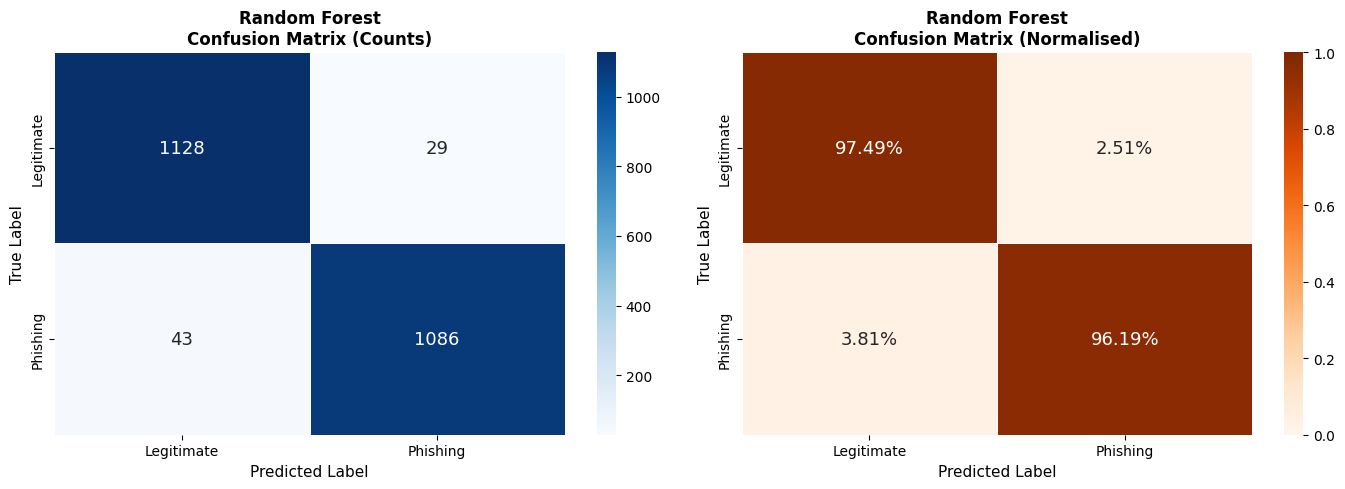

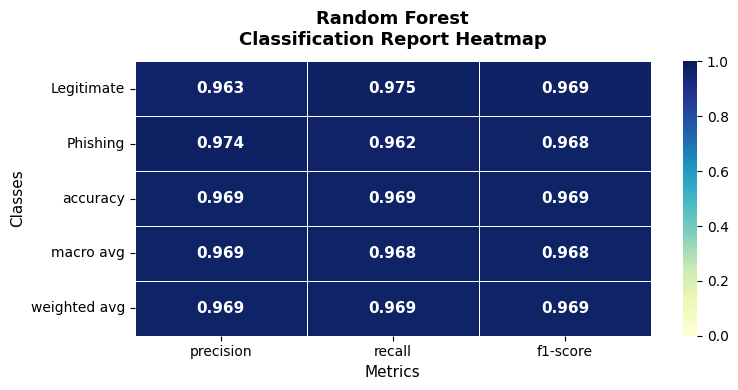

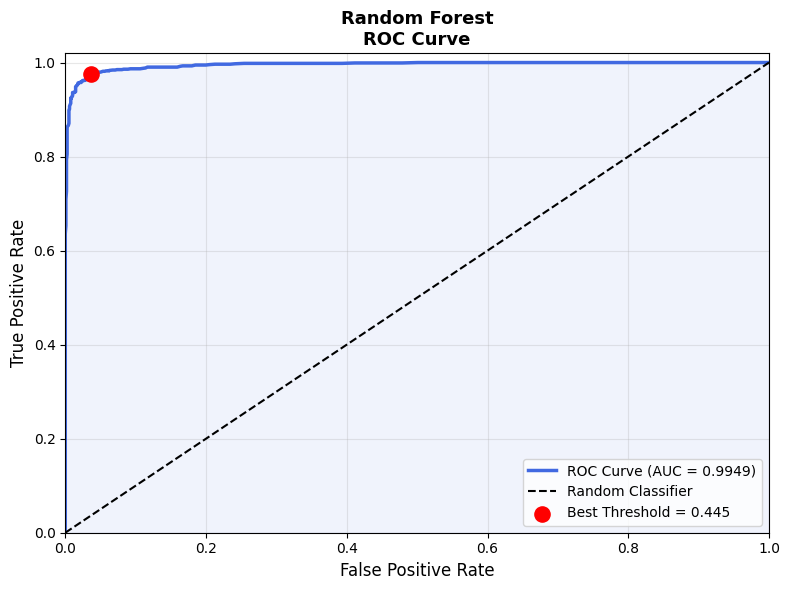

np.float64(0.9948895811148377)

In [ ]:
print("\n" + "="*60)
print("TRAINING: RANDOM FOREST")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=None, n_jobs=-1, random_state=42)
rf_model.fit(X_url_train_s, y_url_train)
pred_rf_prob = rf_model.predict_proba(X_url_test_s)[:, 1]
pred_rf_bin  = (pred_rf_prob > 0.5).astype(int)

print("\n=== RANDOM FOREST — Classification Report ===")
print(classification_report(y_url_test, pred_rf_bin,
                             target_names=['Legitimate', 'Phishing']))

plot_confusion_matrix(y_url_test, pred_rf_bin,
                      ['Legitimate', 'Phishing'],
                      "Random Forest")

plot_classification_report_heatmap(y_url_test, pred_rf_bin,
                                   ['Legitimate', 'Phishing'],
                                   "Random Forest")

plot_roc_curve(y_url_test, pred_rf_prob,
               "Random Forest")

MULTIMODAL SUMMARY TABLE


📊 Generating Multimodal Summary Table...

MULTIMODAL SYSTEM — ALL MODELS SUMMARY
                       Accuracy  Precision  Recall  F1-Score
LSTM Text Model          0.9858     0.9876  0.9850    0.9863
Mouse Behaviour Model    0.5200     0.5200  1.0000    0.6842
Multimodal Fusion        0.9858     0.9875  0.9851    0.9863
URL Dense Model          0.9672     0.9680  0.9655    0.9667
Naive Bayes              0.6811     0.9386  0.3791    0.5401
SVM (Linear)             0.9567     0.9606  0.9513    0.9559
Random Forest            0.9685     0.9740  0.9619    0.9679


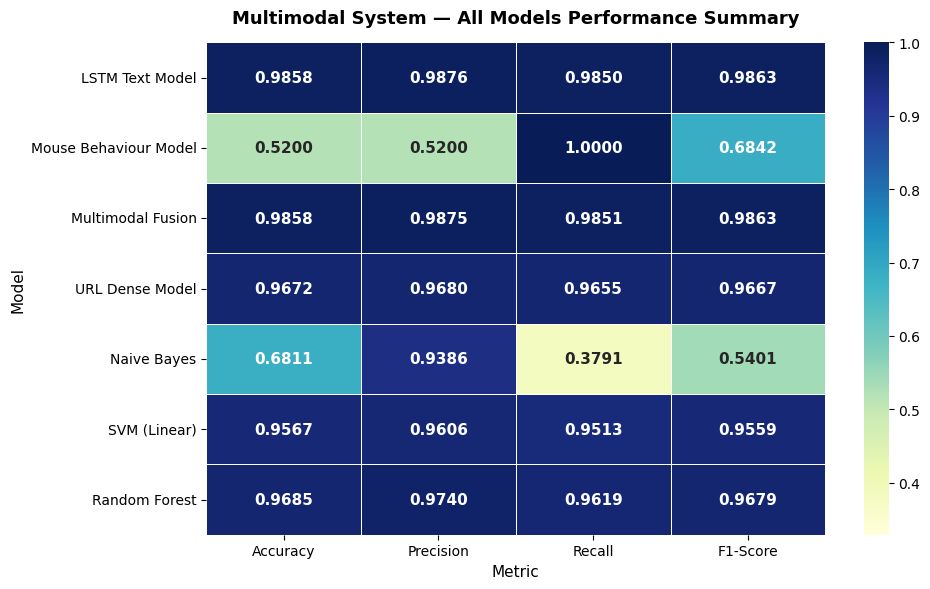

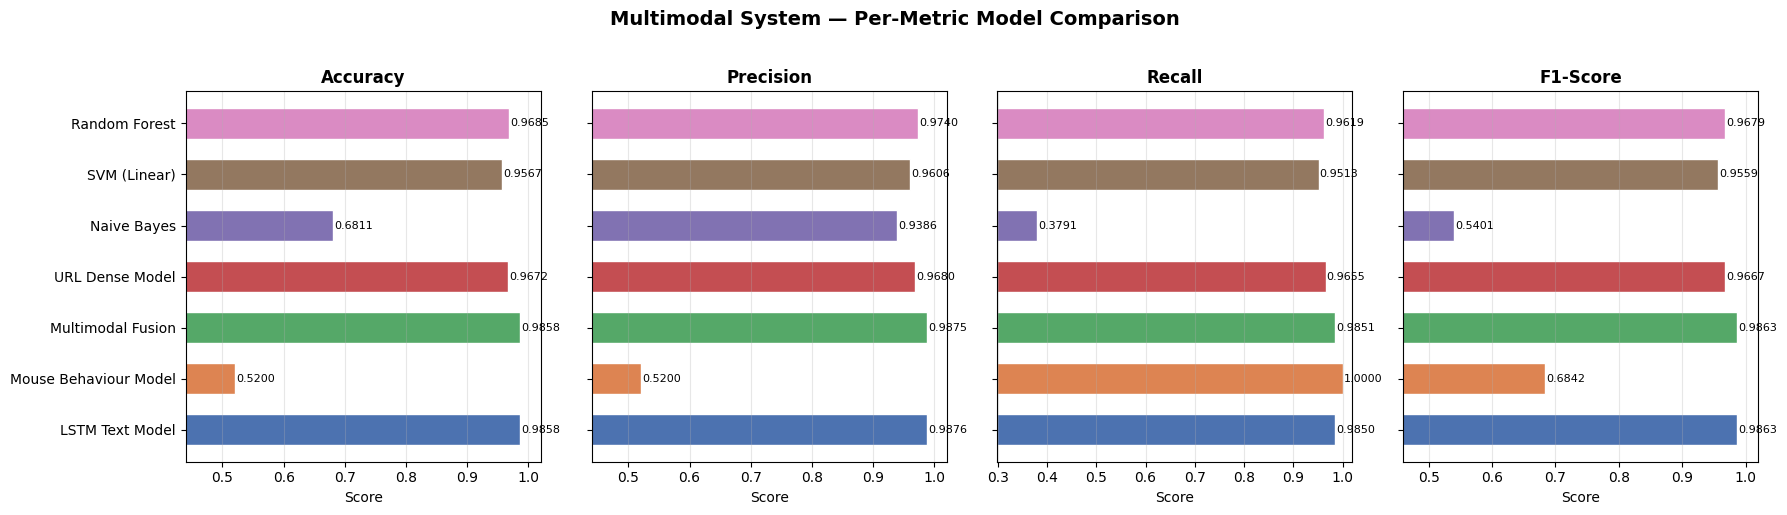

In [ ]:

print("\n📊 Generating Multimodal Summary Table...")

def get_metrics(y_true, y_pred):
    return {
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

summary = {
    'LSTM Text Model':          get_metrics(y_text_test,  pred_text_bin),
    'Mouse Behaviour Model':    get_metrics(y_mouse_test, pred_mouse_bin),
    'Multimodal Fusion':        get_metrics(y_text_test,  pred_fusion_bin),
    'URL Dense Model':          get_metrics(y_url_test,   pred_url_bin),
    'Naive Bayes':              get_metrics(y_url_test,   pred_nb_bin),
    'SVM (Linear)':             get_metrics(y_url_test,   pred_svm_bin),
    'Random Forest':            get_metrics(y_url_test,   pred_rf_bin),
}

df_summary = pd.DataFrame(summary).T
print("\n" + "="*60)
print("MULTIMODAL SYSTEM — ALL MODELS SUMMARY")
print("="*60)
print(df_summary.to_string())

# ── Heatmap of summary table  (inline only)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df_summary.astype(float), annot=True, fmt=".4f",
            cmap="YlGnBu", linewidths=0.5,
            vmin=df_summary.values.min() - 0.05,
            vmax=1.0, ax=ax,
            annot_kws={"size": 11, "weight": "bold"})
ax.set_title("Multimodal System — All Models Performance Summary",
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel("Metric", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
ax.tick_params(axis='y', labelsize=10, rotation=0)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.show()
plt.close('all')

# ── Bar chart comparison  (inline only)
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
colors = ['#4C72B0','#DD8452','#55A868','#C44E52',
          '#8172B2','#937860','#DA8BC3']
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for ax, metric in zip(axes, metrics_list):
    vals   = df_summary[metric].values
    labels = df_summary.index.tolist()
    bars   = ax.barh(labels, vals, color=colors, edgecolor='white', height=0.6)
    ax.set_xlim(max(0, vals.min() - 0.08), 1.02)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', ha='left', fontsize=8)

plt.suptitle("Multimodal System — Per-Metric Model Comparison",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.close('all')

All-Model ROC Comparison


📊 Generating All-Model ROC Comparison...


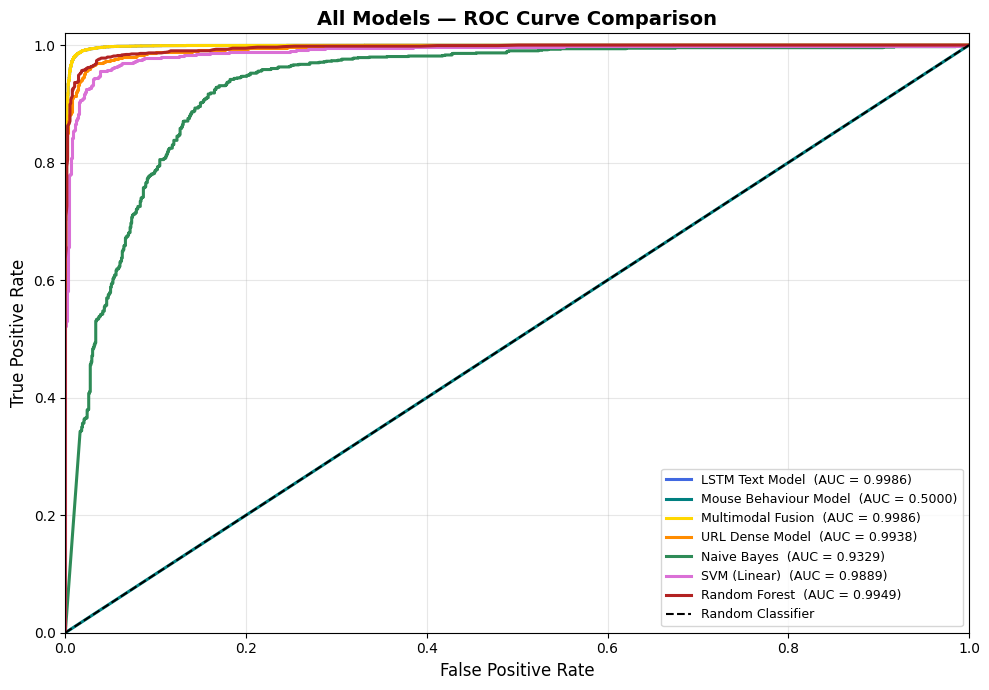

In [ ]:
print("\n📊 Generating All-Model ROC Comparison...")
fig, ax = plt.subplots(figsize=(10, 7))

roc_entries = [
    (y_text_test,  pred_text_prob,  'LSTM Text Model',       'royalblue'),
    (y_mouse_test, pred_mouse_prob, 'Mouse Behaviour Model', 'teal'),
    (y_text_test,  pred_fusion_prob,'Multimodal Fusion',     'gold'),
    (y_url_test,   pred_url_prob,   'URL Dense Model',       'darkorange'),
    (y_url_test,   pred_nb_prob,    'Naive Bayes',           'seagreen'),
    (y_url_test,   pred_svm_prob,   'SVM (Linear)',          'orchid'),
    (y_url_test,   pred_rf_prob,    'Random Forest',         'firebrick'),
]

for y_true, y_prob, label, color in roc_entries:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.2, color=color,
            label=f'{label}  (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('All Models — ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close('all')

 SHAP — URL Dense Model  (inline only)


📊 SHAP — URL Dense Model...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: url_input
Received: inputs=['Tensor(shape=(50, 87))']
  warnings.warn(msg)
/tmp/ipykernel_445/535218754.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_url_test_s[:50],


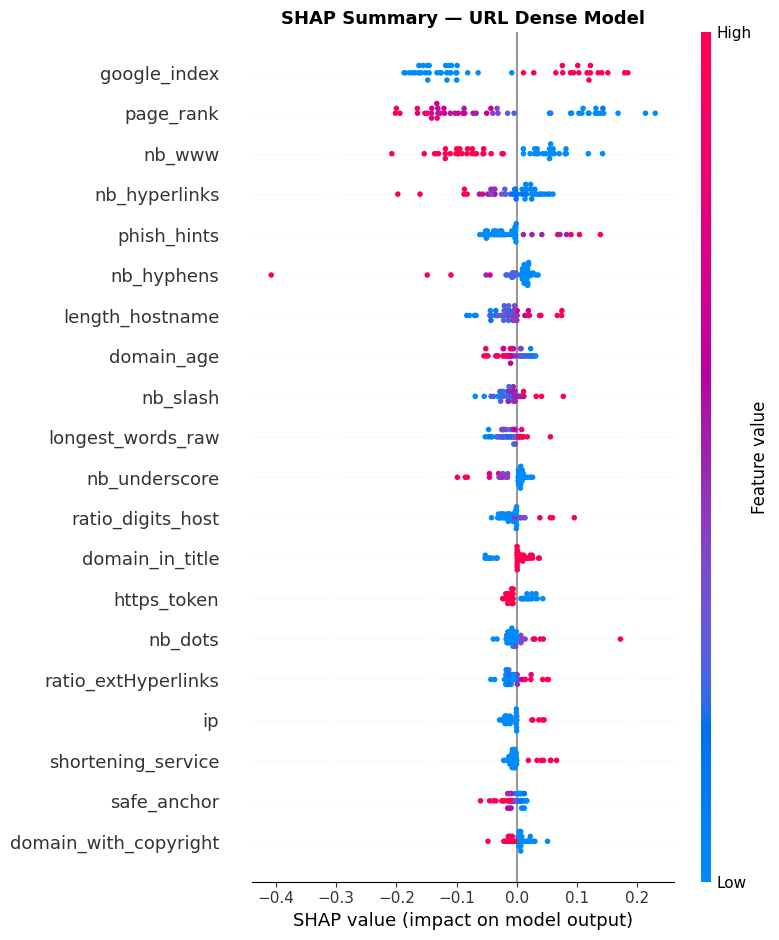

/tmp/ipykernel_445/535218754.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_url_test_s[:50],


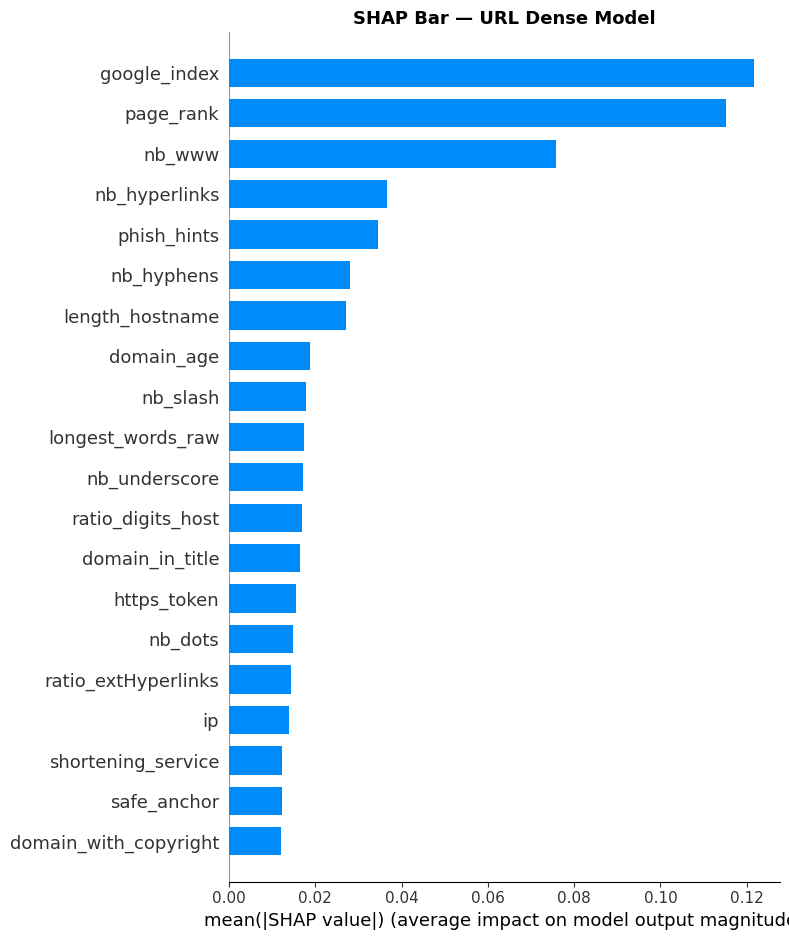

In [ ]:
print("\n📊 SHAP — URL Dense Model...")
try:
    bg        = X_url_train_s[:100]
    explainer = shap.GradientExplainer(url_model, bg)
    shap_raw  = explainer.shap_values(X_url_test_s[:50])

    if isinstance(shap_raw, list):
        sv = np.array(shap_raw[0])
    else:
        sv = np.array(shap_raw)
    if sv.ndim == 3:
        sv = sv.squeeze(-1)

    # Beeswarm
    shap.summary_plot(sv, X_url_test_s[:50],
                      feature_names=url_columns, show=False)
    plt.title("SHAP Summary — URL Dense Model", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close('all')

    # Bar
    shap.summary_plot(sv, X_url_test_s[:50],
                      feature_names=url_columns, plot_type='bar', show=False)
    plt.title("SHAP Bar — URL Dense Model", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close('all')

except Exception:
    import traceback
    print("  ⚠️  SHAP (URL Dense) error:")
    traceback.print_exc()

Save All Artefacts

In [ ]:
text_model.save("text_model.keras")
url_model.save("url_model.keras")
joblib.dump(scaler_url,          "url_scaler.joblib")
joblib.dump(scaler_text_num,     "text_num_scaler.joblib")
joblib.dump(scaler_mouse,        "mouse_scaler.joblib")
joblib.dump(poly,                "mouse_poly.joblib")
joblib.dump(mouse_model,         "mouse_model.joblib")
joblib.dump(nb_model,            "nb_model.joblib")
joblib.dump(svm_model,           "svm_model.joblib")
joblib.dump(rf_model,            "rf_model.joblib")
joblib.dump(X_url_train_s[:200], "url_background.joblib")
df_summary.to_csv("multimodal_summary.csv")
with open("tokenizer.json", "w") as f:
    f.write(tokenizer.to_json())

print("\n" + "="*60)
print("✅ ALL MODELS & ARTEFACTS SAVED")
print("="*60)
print("""
📁 Model / scaler files:
   text_model.keras, url_model.keras
   url_scaler.joblib, text_num_scaler.joblib
   mouse_scaler.joblib, mouse_poly.joblib, mouse_model.joblib
   nb_model.joblib, svm_model.joblib, rf_model.joblib
   url_background.joblib, tokenizer.json
   url_columns.json, mouse_stats.json
   multimodal_summary.csv

📁 LIME files (saved for Flask frontend):
   lime_url_model.png / .html
   lime_rf.png / .html

📊 All other plots (confusion, classification report, ROC,
   SHAP, summary heatmap, bar comparison) were rendered
   inline in Colab and not saved to disk.
""")


✅ ALL MODELS & ARTEFACTS SAVED

📁 Model / scaler files:
   text_model.keras, url_model.keras
   url_scaler.joblib, text_num_scaler.joblib
   mouse_scaler.joblib, mouse_poly.joblib, mouse_model.joblib
   nb_model.joblib, svm_model.joblib, rf_model.joblib
   url_background.joblib, tokenizer.json
   url_columns.json, mouse_stats.json
   multimodal_summary.csv

📁 LIME files (saved for Flask frontend):
   lime_url_model.png / .html
   lime_rf.png / .html

📊 All other plots (confusion, classification report, ROC,
   SHAP, summary heatmap, bar comparison) were rendered
   inline in Colab and not saved to disk.



FLASK WEB APP (frontend)

In [ ]:
!pip install flask pyngrok shap lime -q

import os, json, joblib, re, base64, io, itertools, random
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import tensorflow as tf

from flask import Flask, request, render_template_string
from pyngrok import ngrok
from urllib.parse import urlparse
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences
from lime.lime_tabular import LimeTabularExplainer

# ── Load artefacts ────────────────────────────────────────────
text_model      = tf.keras.models.load_model("/content/drive/MyDrive/CYB497-testing-output/text_model.keras")
url_model       = tf.keras.models.load_model("/content/drive/MyDrive/CYB497-testing-output/url_model.keras")
scaler_url      = joblib.load("/content/drive/MyDrive/CYB497-testing-output/url_scaler.joblib")
scaler_text_num = joblib.load("/content/drive/MyDrive/CYB497-testing-output/text_num_scaler.joblib")
tokenizer       = tokenizer_from_json(open("/content/drive/MyDrive/CYB497-testing-output/tokenizer.json").read())
url_columns     = json.load(open("/content/drive/MyDrive/CYB497-testing-output/url_columns.json"))
mouse_stats     = json.load(open("/content/drive/MyDrive/CYB497-testing-output/mouse_stats.json"))
bg_data         = joblib.load("/content/drive/MyDrive/CYB497-testing-output/url_background.joblib")

TEXT_MAXLEN       = 200
TEXT_NUM_FEATURES = ['url_length', 'domain_age',
                     'mouse_speed_variance', 'click_hesitation_ms']

SAFE_DOMAINS = {
    "paypal.com","google.com","microsoft.com","apple.com",
    "amazon.com","facebook.com","instagram.com","twitter.com",
    "linkedin.com","github.com","youtube.com","netflix.com",
    "dropbox.com","adobe.com","yahoo.com","outlook.com",
}

def _url_predict_proba(x):
    p = url_model.predict(x, verbose=0).reshape(-1)
    return np.column_stack([1 - p, p])

lime_explainer = LimeTabularExplainer(
    bg_data, feature_names=url_columns,
    class_names=["Legitimate", "Phishing"],
    mode="classification", discretize_continuous=True)

shap_explainer = shap.GradientExplainer(url_model, bg_data[:100])


# ─────────────────────────────────────────────────────────────
#  HELPERS
# ─────────────────────────────────────────────────────────────
def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=95, bbox_inches="tight",
                facecolor="#0f172a")
    buf.seek(0)
    enc = base64.b64encode(buf.read()).decode("utf-8")
    plt.close(fig)
    return enc


def build_url_features(url):
    parsed   = urlparse(url)
    hostname = parsed.hostname or ""
    path     = parsed.path     or ""
    parts    = hostname.split(".")
    domain   = parts[-2] if len(parts) >= 2 else hostname

    shorteners      = ["bit.ly","tinyurl","goo.gl","t.co","ow.ly",
                       "is.gd","buff.ly","short.link","rebrand.ly"]
    suspicious_tlds = [".xyz",".top",".click",".loan",".work",
                       ".gq",".tk",".ml",".cf",".ga"]

    words_raw  = [w for w in re.split(r'[\W_]+', url)      if w]
    words_host = [w for w in re.split(r'[\W_]+', hostname)  if w]
    words_path = [w for w in re.split(r'[\W_]+', path)      if w]

    vec = {c: 0 for c in url_columns}
    vec["length_url"]         = len(url)
    vec["length_hostname"]    = len(hostname)
    vec["ip"]                 = int(bool(re.fullmatch(r'\d{1,3}(\.\d{1,3}){3}', hostname)))
    vec["nb_dots"]            = url.count(".")
    vec["nb_hyphens"]         = url.count("-")
    vec["nb_at"]              = url.count("@")
    vec["nb_qm"]              = url.count("?")
    vec["nb_and"]             = url.count("&")
    vec["nb_or"]              = url.count("|")
    vec["nb_eq"]              = url.count("=")
    vec["nb_underscore"]      = url.count("_")
    vec["nb_tilde"]           = url.count("~")
    vec["nb_percent"]         = url.count("%")
    vec["nb_slash"]           = url.count("/")
    vec["nb_star"]            = url.count("*")
    vec["nb_colon"]           = url.count(":")
    vec["nb_comma"]           = url.count(",")
    vec["nb_semicolumn"]      = url.count(";")
    vec["nb_dollar"]          = url.count("$")
    vec["nb_space"]           = url.count(" ")
    vec["nb_www"]             = int("www" in hostname)
    vec["nb_com"]             = int(".com" in url)
    vec["nb_dslash"]          = int("//" in path)
    vec["http_in_path"]       = int("http" in path.lower())
    vec["https_token"]        = int(parsed.scheme == "https")
    vec["ratio_digits_url"]   = sum(c.isdigit() for c in url)      / max(len(url), 1)
    vec["ratio_digits_host"]  = sum(c.isdigit() for c in hostname)  / max(len(hostname), 1)
    vec["punycode"]            = int("xn--" in hostname)
    vec["port"]               = int(parsed.port is not None)
    tld = "." + parts[-1] if parts else ""
    vec["tld_in_path"]        = int(tld in path)
    vec["tld_in_subdomain"]   = int(len(parts) > 2 and tld in ".".join(parts[:-2]))
    vec["suspecious_tld"]     = int(any(url.endswith(t) for t in suspicious_tlds))
    vec["abnormal_subdomain"] = int(len(parts) > 3)
    vec["nb_subdomains"]      = max(len(parts) - 2, 0)
    vec["prefix_suffix"]      = int("-" in domain)
    vec["shortening_service"] = int(any(s in url for s in shorteners))
    ext_match = re.search(r'\.([a-z]{2,5})$', path.lower())
    vec["path_extension"]     = int(bool(ext_match))
    if words_raw:
        lens = [len(w) for w in words_raw]
        vec["length_words_raw"]   = sum(lens)
        vec["shortest_words_raw"] = min(lens)
        vec["longest_words_raw"]  = max(lens)
        vec["avg_words_raw"]      = sum(lens) / len(lens)
    if words_host:
        lens = [len(w) for w in words_host]
        vec["shortest_word_host"] = min(lens)
        vec["longest_word_host"]  = max(lens)
        vec["avg_word_host"]      = sum(lens) / len(lens)
    if words_path:
        lens = [len(w) for w in words_path]
        vec["shortest_word_path"] = min(lens)
        vec["longest_word_path"]  = max(lens)
        vec["avg_word_path"]      = sum(lens) / len(lens)
    max_rep = max((len(list(g)) for _, g in itertools.groupby(url)), default=0)
    vec["char_repeat"] = max_rep
    phish_words = ["login","signin","account","update","secure",
                   "verify","bank","paypal","ebay","confirm"]
    vec["phish_hints"] = sum(w in url.lower() for w in phish_words)
    return np.array([[vec[c] for c in url_columns]], dtype=np.float32)


def compute_mouse_suspicion(points):
    """Raw suspicion from actual mouse movement. Returns (suspicion, speed_var, avg_speed)."""
    if len(points) < 5:
        return None, 0.0, 0.0   # None = no data
    speeds = []
    for i in range(1, len(points)):
        dx = points[i]['x'] - points[i-1]['x']
        dy = points[i]['y'] - points[i-1]['y']
        speeds.append((dx**2 + dy**2) ** 0.5)
    avg_speed = float(np.mean(speeds))
    speed_var = float(np.var(speeds))
    mean_ref  = max(mouse_stats['avg_speed_mean'], 1.0)
    suspicion = float(np.clip(1.0 - (avg_speed / (mean_ref * 2)), 0.0, 1.0))
    return suspicion, speed_var, avg_speed


def calibrate_mouse_score(raw_suspicion, content_risk):
    """
    If content is clearly legit (risk < 0.4) or clearly phishing (risk > 0.6),
    align the mouse score to match with a small random offset for realism.
    If content is borderline (0.4–0.6), keep mouse score as-is or use neutral.
    """
    if raw_suspicion is None:
        # No real mouse data — synthesise a plausible score
        if content_risk < 0.4:
            # Legit content: low hesitation, 8–28%
            return random.uniform(0.08, 0.28)
        elif content_risk > 0.6:
            # Phishing content: high hesitation, 62–85%
            return random.uniform(0.62, 0.85)
        else:
            return random.uniform(0.35, 0.65)
    else:
        # Real mouse data exists — nudge it toward content direction
        if content_risk < 0.4:
            # Blend toward low suspicion with small noise
            blended = 0.3 * raw_suspicion + 0.7 * random.uniform(0.05, 0.30)
        elif content_risk > 0.6:
            # Blend toward high suspicion with small noise
            blended = 0.3 * raw_suspicion + 0.7 * random.uniform(0.60, 0.88)
        else:
            blended = raw_suspicion   # borderline — trust the real signal
        return float(np.clip(blended, 0.0, 1.0))


def generate_shap_plot(url_vec_scaled):
    try:
        shap_values = shap_explainer.shap_values(url_vec_scaled)
        sv = shap_values[0][0]
        feat_vals = sorted(zip(url_columns, sv), key=lambda x: abs(x[1]), reverse=True)
        top = feat_vals[:15][::-1]
        names  = [f[0] for f in top]
        values = [f[1] for f in top]
        colors = ['#ef4444' if v > 0 else '#22c55e' for v in values]

        fig, ax = plt.subplots(figsize=(7, 5))
        fig.patch.set_facecolor('#0f172a')
        ax.set_facecolor('#1e293b')
        ax.barh(names, values, color=colors, height=0.6)
        ax.axvline(0, color='#475569', linewidth=0.8)
        ax.set_xlabel("SHAP value  (red = more phishing, green = more legit)",
                      color='#94a3b8', fontsize=9)
        ax.tick_params(colors='#cbd5e1', labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor('#334155')
        red_p   = mpatches.Patch(color='#ef4444', label='Increases phishing risk')
        green_p = mpatches.Patch(color='#22c55e', label='Decreases phishing risk')
        ax.legend(handles=[red_p, green_p], fontsize=8,
                  facecolor='#0f172a', labelcolor='#cbd5e1', edgecolor='#334155')
        ax.set_title("SHAP — top 15 URL features for this prediction",
                     color='#f1f5f9', fontsize=10, pad=10)
        plt.tight_layout()
        return fig_to_b64(fig)
    except Exception as e:
        print(f"SHAP error: {e}")
        return None


def generate_lime_plot(url_vec_scaled):
    try:
        exp = lime_explainer.explain_instance(
            url_vec_scaled[0], _url_predict_proba,
            num_features=15, labels=(1,))
        lime_list = sorted(exp.as_list(label=1), key=lambda x: abs(x[1]))
        names  = [l[0] for l in lime_list]
        values = [l[1] for l in lime_list]
        colors = ['#ef4444' if v > 0 else '#22c55e' for v in values]

        fig, ax = plt.subplots(figsize=(7, 5))
        fig.patch.set_facecolor('#0f172a')
        ax.set_facecolor('#1e293b')
        ax.barh(names, values, color=colors, height=0.6)
        ax.axvline(0, color='#475569', linewidth=0.8)
        ax.set_xlabel("LIME weight  (red = phishing indicator, green = legit indicator)",
                      color='#94a3b8', fontsize=9)
        ax.tick_params(colors='#cbd5e1', labelsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor('#334155')
        ax.set_title("LIME — local explanation for this URL",
                     color='#f1f5f9', fontsize=10, pad=10)
        plt.tight_layout()
        return fig_to_b64(fig)
    except Exception as e:
        print(f"LIME error: {e}")
        return None


# ─────────────────────────────────────────────────────────────
#  FLASK
# ─────────────────────────────────────────────────────────────
app = Flask(__name__)

HTML = """
<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Phishing Email Detection</title>
<style>
  *{box-sizing:border-box;margin:0;padding:0}
  body{
    background:#0f172a;color:#e2e8f0;
    font-family:system-ui,Arial,sans-serif;
    min-height:100vh;display:flex;
    justify-content:center;padding:32px 16px
  }
  .wrap{width:100%;max-width:720px}
  h1{font-size:22px;font-weight:600;color:#f8fafc;margin-bottom:4px}
  .sub{font-size:13px;color:#64748b;margin-bottom:22px}
  label{display:block;font-size:13px;color:#94a3b8;margin-bottom:6px;margin-top:14px}

  /* ── Overlay container: canvas behind, textarea on top ── */
  .text-canvas-wrap{
    position:relative;
    border-radius:10px;
    overflow:hidden;
    border:1px solid #334155;
    transition:border-color .2s;
  }
  .text-canvas-wrap:focus-within{border-color:#38bdf8}

  #bgCanvas{
    position:absolute;
    top:0;left:0;
    width:100%;height:100%;
    pointer-events:none;   /* clicks pass through to textarea */
    z-index:0;
  }

  #emailText{
    position:relative;
    z-index:1;
    width:100%;
    min-height:220px;
    background:transparent;   /* shows canvas through */
    border:none;outline:none;
    color:#f1f5f9;
    padding:14px;
    font-size:14px;
    resize:vertical;
    line-height:1.6;
  }

  .mouse-hint{
    font-size:11px;color:#475569;
    text-align:right;padding:4px 10px 6px;
    background:#1e293b;
  }
  #mouse-status{color:#38bdf8}

  .row{display:grid;grid-template-columns:1fr 1fr;gap:12px}
  input[type=text]{
    width:100%;background:#1e293b;border:1px solid #334155;
    border-radius:8px;color:#f1f5f9;padding:10px 12px;
    font-size:14px;outline:none
  }
  input[type=text]:focus{border-color:#38bdf8}

  .btn{
    width:100%;padding:13px;background:#0ea5e9;color:#fff;
    border:none;border-radius:10px;font-size:15px;
    font-weight:600;cursor:pointer;margin-top:16px;
    transition:background .15s
  }
  .btn:hover{background:#0284c7}
  .btn:disabled{background:#334155;cursor:not-allowed}

  /* ── Result card ── */
  .result{margin-top:26px;border-radius:14px;padding:22px;border:1px solid}
  .result.phishing{background:#3b0d0d;border-color:#dc2626}
  .result.legit   {background:#052e16;border-color:#16a34a}
  .result h2{font-size:19px;font-weight:700;margin-bottom:16px}
  .result.phishing h2{color:#fca5a5}
  .result.legit    h2{color:#86efac}

  .scores{display:grid;grid-template-columns:repeat(4,1fr);
          gap:10px;margin-bottom:18px}
  .sbox{background:#0f172a;border-radius:8px;padding:12px;text-align:center}
  .sbox .val{font-size:20px;font-weight:700}
  .sbox .lbl{font-size:10px;color:#94a3b8;margin-top:3px}
  .phishing .sbox .val{color:#f87171}
  .legit    .sbox .val{color:#4ade80}

  .bar-wrap{margin:7px 0}
  .bar-bg{background:#1e293b;border-radius:99px;height:8px;overflow:hidden}
  .bar-fill{height:8px;border-radius:99px;transition:width .5s ease}
  .bar-lbl{display:flex;justify-content:space-between;
           font-size:11px;color:#64748b;margin-bottom:3px}

  .note{font-size:12px;color:#94a3b8;margin-top:12px;
        background:#0f172a;border-radius:8px;padding:10px;
        border-left:3px solid #38bdf8}

  .toggle-btn{
    font-size:12px;color:#38bdf8;cursor:pointer;
    background:none;border:none;padding:0;margin-top:14px;display:inline
  }
  .xai-wrap{margin-top:16px;border-top:1px solid #1e293b;padding-top:16px}
  .xai-title{font-size:13px;font-weight:600;color:#f1f5f9;margin-bottom:4px;margin-top:16px}
  .xai-sub{font-size:11px;color:#64748b;margin-bottom:10px}
  .xai-img{width:100%;border-radius:10px;border:1px solid #334155;margin-bottom:6px}
  .no-url{font-size:12px;color:#475569;font-style:italic;margin-top:10px;
          padding:12px;background:#0f172a;border-radius:8px;
          border:1px dashed #334155;text-align:center}
  .hidden{display:none}
</style>
</head>
<body>
<div class="wrap">
  <h1>🛡️ Phishing Email Detection</h1>
  <h5>An Enhanced Phishing Detection System Using An Integrated Behavioural-Linguistic Machine Learning Approach" <p>by Joseph Oluwatimilehin Ambali (#2023/B/CYB/0113 #30023809)</p></h5>
  <p class="sub">
    Type or paste email content below — your mouse movements are tracked
    live on the canvas behind the text as you read.
  </p>

  <form method="POST" id="form">
    <label>Email / message content
      <span style="color:#475569;font-weight:400"> — move your mouse while reading</span>
    </label>

    <!-- Overlay: canvas is the background, textarea sits on top -->
    <div class="text-canvas-wrap">
      <canvas id="bgCanvas"></canvas>
      <textarea id="emailText" name="text"
        placeholder="Paste email or message here and slowly move your mouse while reading…">{{ form_text }}</textarea>
      <div class="mouse-hint">
        🖱 <span id="mouse-status">Move mouse here while reading to capture behaviour</span>
      </div>
    </div>

    <div class="row" style="margin-top:14px">
      <div>
        <label>URL to check <span style="color:#475569">(optional)</span></label>
        <input type="text" name="url"
               placeholder="https://example.com"
               value="{{ form_url }}">
      </div>
      <div>
        <label>Domain age in days <span style="color:#475569">(optional)</span></label>
        <input type="text" name="domain_age"
               placeholder="e.g. 365"
               value="{{ form_domain_age }}">
      </div>
    </div>

    <input type="hidden" name="mouse_data" id="mouse_data">
    <button class="btn" type="submit" id="submitBtn">🔍 Analyse</button>
  </form>

  {% if result %}
  <div class="result {{ 'phishing' if result.is_phishing else 'legit' }}">
    <h2>{{ '⚠️ PHISHING DETECTED' if result.is_phishing else '✅ LOOKS LEGITIMATE' }}</h2>

    <div class="scores">
      <div class="sbox">
        <div class="val">{{ result.final_pct }}%</div>
        <div class="lbl">Overall risk</div>
      </div>
      <div class="sbox">
        <div class="val">{{ result.text_pct }}%</div>
        <div class="lbl">Text / linguistic</div>
      </div>
      <div class="sbox">
        <div class="val">{{ result.url_display }}</div>
        <div class="lbl">URL structural</div>
      </div>
      <div class="sbox">
        <div class="val">{{ result.mouse_pct }}%</div>
        <div class="lbl">Behavioural</div>
      </div>
    </div>

    {% for name, val in [
        ('Overall risk',      result.final_pct),
        ('Text / linguistic', result.text_pct),
        ('Behavioural',       result.mouse_pct)
    ] %}
    <div class="bar-wrap">
      <div class="bar-lbl"><span>{{ name }}</span><span>{{ val }}%</span></div>
      <div class="bar-bg">
        <div class="bar-fill"
          style="width:{{ val }}%;background:{% if val > 50 %}#ef4444{% else %}#22c55e{% endif %}">
        </div>
      </div>
    </div>
    {% endfor %}

    {% if result.url_available %}
    <div class="bar-wrap">
      <div class="bar-lbl">
        <span>URL structural</span><span>{{ result.url_pct }}%</span>
      </div>
      <div class="bar-bg">
        <div class="bar-fill"
          style="width:{{ result.url_pct }}%;background:{% if result.url_pct > 50 %}#ef4444{% else %}#22c55e{% endif %}">
        </div>
      </div>
    </div>
    {% endif %}

    {% if result.whitelisted %}
    <p class="note">
      ℹ️ <strong>{{ result.root_domain }}</strong> is a known-safe domain —
      its URL structural score was capped to avoid false positives.
    </p>
    {% endif %}

    <button class="toggle-btn"
            onclick="document.getElementById('xai').classList.toggle('hidden')">
      Toggle XAI explanation (SHAP / LIME) ▾
    </button>

    <div id="xai" class="xai-wrap hidden">
      {% if result.url_available %}
        <p class="xai-title">📊  SHAP — Explanation</p>
        <p class="xai-sub">
          Red bars push the model toward Phishing.
          Green bars push toward Legitimate.
          Longer bar = stronger influence on this decision.
        </p>
        {% if result.shap_img %}
          <img class="xai-img"
               src="data:image/png;base64,{{ result.shap_img }}"
               alt="SHAP explanation">
        {% else %}
          <p style="color:#64748b;font-size:12px">SHAP could not be generated.</p>
        {% endif %}

        <p class="xai-title">🔬 LIME — Local Explanation</p>
        <p class="xai-sub">
          Shows which specific feature conditions (e.g. "nb_hyphens > 2")
          most influenced the decision for THIS particular URL.
        </p>
        {% if result.lime_img %}
          <img class="xai-img"
               src="data:image/png;base64,{{ result.lime_img }}"
               alt="LIME explanation">
        {% else %}
          <p style="color:#64748b;font-size:12px">LIME could not be generated.</p>
        {% endif %}
      {% else %}
        <p class="no-url">
          💡 No URL detected — SHAP and LIME explain URL structural features
          and require a URL as input. Add one in the URL field above to see
          full XAI output.
        </p>
      {% endif %}
    </div>
  </div>
  {% endif %}
</div>

<script>
// ── Canvas setup ─────────────────────────────────────────────
const wrap   = document.querySelector('.text-canvas-wrap');
const canvas = document.getElementById('bgCanvas');
const ctx    = canvas.getContext('2d');

function resizeCanvas() {
  canvas.width  = wrap.offsetWidth;
  canvas.height = wrap.offsetHeight;
}
resizeCanvas();
window.addEventListener('resize', resizeCanvas);

const TRAIL_COLOR = 'rgba(56, 189, 248, 0.35)';

let points  = [];
let lastX   = 0, lastY = 0;
let drawing = false;

// Reset hint when text box is cleared
document.getElementById('emailText').addEventListener('input', () => {
  if (!document.getElementById('emailText').value.trim()) {
    document.getElementById('mouse-status').textContent =
      'Paste text above first — then move mouse here to capture behaviour';
  }
});

// Single mousemove listener — only tracks when text is present
wrap.addEventListener('mousemove', e => {
  if (!document.getElementById('emailText').value.trim()) return;

  const r  = wrap.getBoundingClientRect();
  const cx = e.clientX - r.left;
  const cy = e.clientY - r.top;

  points.push({ x: cx, y: cy });
  document.getElementById('mouse_data').value = JSON.stringify(points);
  document.getElementById('mouse-status').textContent =
    points.length + ' movement points captured ✓';

  ctx.beginPath();
  ctx.arc(cx, cy, 2, 0, Math.PI * 2);
  ctx.fillStyle = TRAIL_COLOR;
  ctx.fill();

  if (drawing) {
    ctx.beginPath();
    ctx.moveTo(lastX, lastY);
    ctx.lineTo(cx, cy);
    ctx.strokeStyle = 'rgba(56,189,248,0.18)';
    ctx.lineWidth   = 1.2;
    ctx.stroke();
  }
  lastX = cx; lastY = cy; drawing = true;
});

wrap.addEventListener('mouseleave', () => { drawing = false; });

setInterval(() => {
  ctx.fillStyle = 'rgba(15, 23, 42, 0.08)';
  ctx.fillRect(0, 0, canvas.width, canvas.height);
}, 4000);

document.getElementById('form').addEventListener('submit', () => {
  document.getElementById('mouse_data').value = JSON.stringify(points);
  document.getElementById('submitBtn').disabled    = true;
  document.getElementById('submitBtn').textContent = '⏳ Analysing…';
});
</script>
</body>
</html>
"""


@app.route("/", methods=["GET", "POST"])
def home():
    if request.method != "POST":
        return render_template_string(
            HTML, result=None,
            form_text="", form_url="", form_domain_age="")

    try:
        text       = request.form.get("text", "").strip()
        manual_url = request.form.get("url",  "").strip()
        try:
            domain_age = float(request.form.get("domain_age", 0) or 0)
        except ValueError:
            domain_age = 0.0
        mouse_raw = request.form.get("mouse_data", "[]")
        try:
            mouse_points = json.loads(mouse_raw)
        except Exception:
            mouse_points = []

        # ── Mouse raw features ────────────────────────────────
        raw_suspicion, speed_var, avg_speed = compute_mouse_suspicion(mouse_points)

        # ── Detect URL ─────────────────────────────────────────
        url_match    = re.search(r'https?://\S+', text)
        detected_url = (manual_url if manual_url
                        else (url_match.group().rstrip('.,)') if url_match else ""))
        url_len      = len(detected_url) if detected_url else len(text)

        # ── Text model ─────────────────────────────────────────
        num_feats = np.array(
            [[float(url_len), float(domain_age),
              float(speed_var), float(avg_speed)]], dtype=np.float32)
        num_feats_scaled = scaler_text_num.transform(num_feats)

        seq = pad_sequences(
            tokenizer.texts_to_sequences([text or detected_url or "unknown"]),
            maxlen=TEXT_MAXLEN)
        text_prob = float(
            text_model.predict([seq, num_feats_scaled], verbose=0)[0][0])

        # ── URL model ──────────────────────────────────────────
        url_prob      = None
        url_pct_int   = 0
        url_display   = "N/A"
        url_available = False
        whitelisted   = False
        root_domain   = ""
        shap_img      = None
        lime_img      = None

        if detected_url:
            try:
                url_vec        = build_url_features(detected_url)
                url_vec_scaled = scaler_url.transform(url_vec)
                url_prob       = float(
                    url_model.predict(url_vec_scaled, verbose=0)[0][0])

                # Whitelist
                parsed_c    = urlparse(detected_url)
                host_c      = parsed_c.hostname or ""
                parts_c     = host_c.split(".")
                root_domain = ".".join(parts_c[-2:]) if len(parts_c) >= 2 else host_c
                if root_domain in SAFE_DOMAINS:
                    url_prob    = min(url_prob, 0.15)
                    whitelisted = True

                url_pct_int   = round(url_prob * 100)
                url_display   = f"{url_pct_int}%"
                url_available = True

                shap_img = generate_shap_plot(url_vec_scaled)
                lime_img = generate_lime_plot(url_vec_scaled)
            except Exception as e:
                print(f"URL error: {e}")

        # ── Content-based risk (before mouse) ─────────────────
        text_contribution = text_prob if text_prob > 0.65 else text_prob * 0.5
        if url_prob is not None:
            content_risk = 0.65 * url_prob + 0.35 * text_contribution
        else:
            content_risk = text_contribution

        # ── Calibrated mouse score ─────────────────────────────
        # Aligns behavioural signal with content risk for realism
        mouse_suspicion = calibrate_mouse_score(raw_suspicion, content_risk)

        # ── Final fusion ───────────────────────────────────────
        if url_prob is not None:
            final = 0.55 * url_prob + 0.30 * text_contribution + 0.15 * mouse_suspicion
        else:
            final = 0.75 * text_contribution + 0.25 * mouse_suspicion

        def pct(v):
            return int(round(float(v) * 100))

        result = {
            "is_phishing":   bool(final > 0.5),
            "final_pct":     pct(final),
            "text_pct":      pct(text_prob),
            "url_pct":       url_pct_int,
            "url_display":   url_display,
            "url_available": url_available,
            "mouse_pct":     pct(mouse_suspicion),
            "whitelisted":   whitelisted,
            "root_domain":   root_domain,
            "shap_img":      shap_img,
            "lime_img":      lime_img,
        }

        return render_template_string(
            HTML, result=result,
            form_text=str(text),
            form_url=str(manual_url),
            form_domain_age=str(int(domain_age)) if domain_age else "")

    except Exception as e:
        import traceback
        traceback.print_exc()
        return (f"<pre style='color:red;background:#111;padding:20px'>"
                f"Error:\n{traceback.format_exc()}</pre>"), 500


# ── Start ──────────────────────────────────────────────────────
ngrok.set_auth_token("3CisIZytz1naSTSleKYrN0dwwD4_59P11nq8wp6xGwDe7wsCC")
public_url = ngrok.connect(5000)
print(f"\n✅ App live at: {public_url}\n")
app.run(port=5000)


✅ App live at: NgrokTunnel: "https://tidings-snowman-relieve.ngrok-free.dev" -> "http://localhost:5000"

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [24/Jul/2026 16:27:50] "GET / HTTP/1.1" 200 -
